In [1]:
import os
import sys
# set working directory
os.chdir("../riemannian_la")
print(os.getcwd())

import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from models import LinearModel, FunctionApproximatorModel
from train import train
from laplace_approx import Laplace
from MCMC_sampler import MCMC_sampler
from getdata import make_loaders, torch_seed, gen_model_data, gen_log_regression_data
from utils import NegLogLik_regression
from integration import integrator
from utils import loss_func_from_target_sigma, make_functional_fwd_xs, functional_loss, functional_loss_for_vmap, sum_loss, neglog_loss, tensify
from discrete_sampler import discrete_function_sampler, discrete_model_sampler
from riemann_sampler import Riemann_sampler, riemann_plotter
from BQ_rays_subspace import BayesianQuadrature_rays
from emukit.quadrature.methods import VanillaBayesianQuadrature, WarpedBayesianQuadratureModel, BoundedBayesianQuadrature
from emukit.quadrature.methods.warpings import SquareRootWarping
from emukit.model_wrappers import GPyModelWrapper
import numpy as np
from models import functional_banana, Model_from_func
import seaborn as sns
import pandas as pd


fig_folder = "../report/figures"
os.makedirs(fig_folder, exist_ok=True)
torch.manual_seed(0)

/Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la


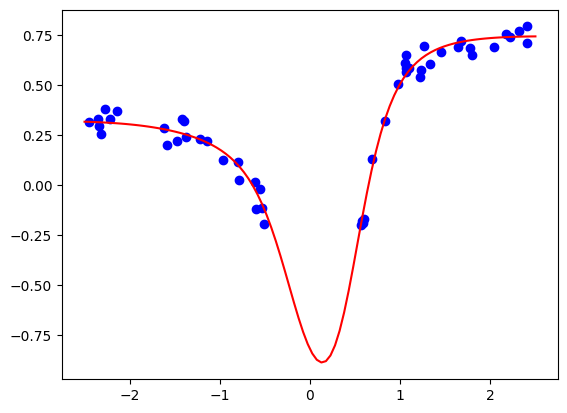

In [2]:
num_features=1
UFA_model = FunctionApproximatorModel(num_features=num_features, hidden_layers=[10,10], num_outputs=1, nonlin = torch.nn.Tanh(), seed=47)

prior_sigma = 1.
target_sigma = 0.05

start_x = -2.5
end_x = 2.5
#input_dist = lambda x: torch.rand(x, num_features)*(end_x-start_x) + start_x
def input_dist(N):
    xs = torch.rand(N*10, num_features)*(end_x-start_x) + start_x
    index = (1-((xs > -.5) & (xs < 0.5)).int()).nonzero()[:,0]
    return xs[index][:N]

train_loader, test_loader = gen_model_data(UFA_model, input_dist, num_train_samples=50, 
                                           num_test_samples=10, noise_std=target_sigma, seed=2, batch_size=1)

pre_trained_params = torch.nn.utils.parameters_to_vector(UFA_model.parameters())
xs, ys = train_loader.dataset.dataset.tensors
xs_plt = torch.linspace(start_x, end_x, 100).unsqueeze(1)
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
ys_plt_pretrained = UFA_model(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, c="r", label="true function")
plt.show()


In [3]:
# Ok, we got some data now. 
# We already know the true mode, but because of the noise we have to post-train it, 
# to be sure that we are actually at the optimal parameters
# We do however start from the true parameters, so we should be able to get there

lr = torch.tensor(0.01)
optimizer = torch.optim.Adam(UFA_model.parameters(), lr=lr)
schedule_factor = 0.0001
epochs= 1000

scheduler = torch.optim.lr_scheduler.LinearLR(optimizer,start_factor=1, end_factor=schedule_factor, total_iters=epochs)

UFA_model, _, _, _, _ = train(UFA_model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, 
              scheduler=scheduler, epochs=epochs, 
          prior_sigma=prior_sigma,
          target_sigma=target_sigma,
          device="cpu", logger_info=None,
          plot=False, plotpath=None, verbose = True, print_every_epoch=100)

trained_params = torch.nn.utils.parameters_to_vector(UFA_model.parameters())


epoch = 100 	train loss: 1.57245, train prediction loss: 1.30856, regularization loss: 0.26389, norm of gradient: 6312.18019, test loss: 3.82022, test accuracy: 0.00, lr: 9.000115e-03
epoch = 200 	train loss: 1.53058, train prediction loss: 1.31126, regularization loss: 0.21932, norm of gradient: 5940.75566, test loss: 3.14752, test accuracy: 0.00, lr: 8.000220e-03
epoch = 300 	train loss: 1.33555, train prediction loss: 1.13471, regularization loss: 0.20084, norm of gradient: 5051.15350, test loss: 2.98574, test accuracy: 0.00, lr: 7.000322e-03
epoch = 400 	train loss: 1.39173, train prediction loss: 1.19545, regularization loss: 0.19628, norm of gradient: 4941.92090, test loss: 2.37312, test accuracy: 0.00, lr: 6.000417e-03
epoch = 500 	train loss: 1.26717, train prediction loss: 1.07778, regularization loss: 0.18939, norm of gradient: 3732.10869, test loss: 2.11970, test accuracy: 0.00, lr: 5.000509e-03
epoch = 600 	train loss: 1.10281, train prediction loss: 0.91974, regularization

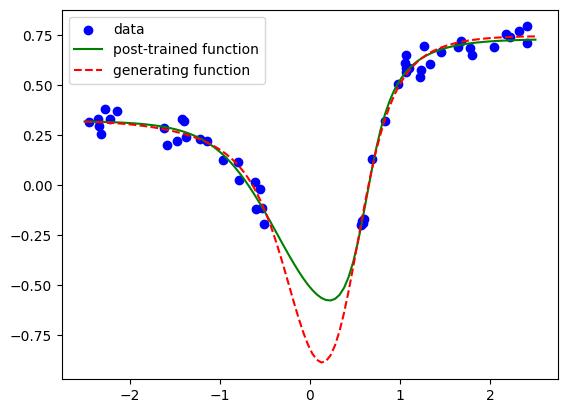

In [4]:
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
ys_plt_trained = UFA_model(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="g", label="post-trained function")
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, label="generating function", linestyle="--", c="r")
plt.legend()
plt.savefig(f"{fig_folder}/post_trained_function.png")

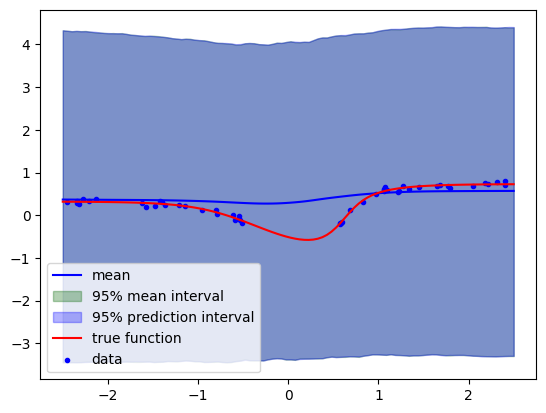

In [5]:
####################################
# Ok, we have trained the model. Now we can try to fit a Laplace approximation to the posterior
####################################
loss_fn = NegLogLik_regression(target_sigma=target_sigma)
laplace = Laplace(UFA_model, xs=xs, ys=ys, prior_sigma=prior_sigma, loss_fn=loss_fn, subspace_rank=0)

_=laplace.fit_subspace(fitting_type="GGN", xs=xs, ys=ys)
#_=laplace.fit(fitting_type="GGN", xs=xs, ys=ys)
#print(f"Covariance: {laplace.covariance}")
#print(f"Mean: {laplace.mean}")

laplace.make_posterior_sample(n_samples=10000)

integral_la, function_values_la, weights_la, posterior_samples_la = integrator(sampler=laplace, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means = integral_la.detach()[:, 0]
means_la = function_values_la.mean(dim=0).detach()
upper95_api_la = function_values_la.quantile(.95, dim=0).detach()
lower95_epi_la = function_values_la.quantile(.05, dim=0).detach()
pred_samples = (torch.distributions.Normal(function_values_la, target_sigma).sample((10,)))
upper95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.05, dim=0).detach()

plt.plot(xs_plt, means_la, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_epi_la[:,0], upper95_api_la[:,0], alpha=0.3, color="darkgreen", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_la[:,0], upper95_both_la[:,0], alpha=0.3, color="blue", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="red", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="blue", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/laplace_approximation_fullrank.png")
plt.show()




# epistemic_var = (function_values_lp[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
# aleatoric_var = target_sigma**2
# plt.plot(xs_plt, means, c="g", label="mean")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
# plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# plt.legend()
# plt.savefig(f"{fig_folder}/laplace_approximation_fullrank.png")
# plt.show()


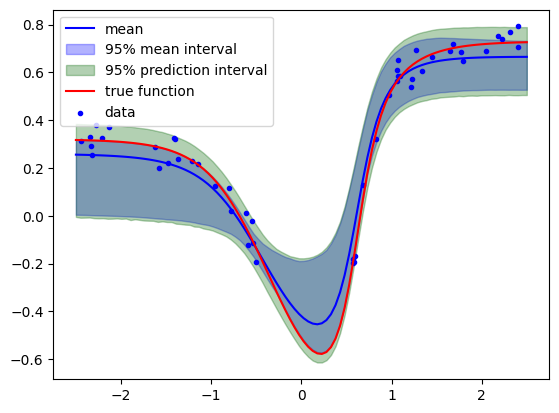

In [6]:
####################################
# Laplace subspace integration
####################################
loss_fn = NegLogLik_regression(target_sigma=target_sigma)
laplace = Laplace(UFA_model, xs=xs, ys=ys, prior_sigma=prior_sigma, loss_fn=loss_fn, n_posterior_samples=100, subspace_rank=2)

_=laplace.fit(fitting_type="GGN", xs=xs, ys=ys)
#print(f"Covariance: {laplace.covariance}")
#print(f"Mean: {laplace.mean}")

laplace.make_posterior_sample(n_samples=10000)
integral_la, function_values_la, weights_la, posterior_samples_la = integrator(sampler=laplace, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means = integral_la.detach()[:, 0]
means_la = function_values_la.mean(dim=0).detach()
upper95_api_la = function_values_la.quantile(.95, dim=0).detach()
lower95_epi_la = function_values_la.quantile(.05, dim=0).detach()
pred_samples = (torch.distributions.Normal(function_values_la, target_sigma).sample((10,)))
upper95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_la = (pred_samples.reshape(pred_samples.shape[0] * pred_samples.shape[1], *pred_samples.shape[2:])).quantile(.05, dim=0).detach()

plt.plot(xs_plt, means_la, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_epi_la[:,0], upper95_api_la[:,0], alpha=0.3, color="blue", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_la[:,0], upper95_both_la[:,0], alpha=0.3, color="darkgreen", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="blue", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/laplace_approximation_subspace_rank2.png")
plt.show()



# means = integral_la.detach()[:, 0]
# epistemic_var = (function_values_la[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
# aleatoric_var = target_sigma**2
# plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# plt.plot(xs_plt[:, 0].detach(), means)
# plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
# plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# plt.legend()
# plt.savefig(f"{fig_folder}/laplace_approximation_subspace_rank1.png")
# plt.show()

# plt.plot(xs_plt, np.sqrt(aleatoric_var + epistemic_var))
# plt.plot(xs_plt, np.sqrt(epistemic_var))
# plt.show()

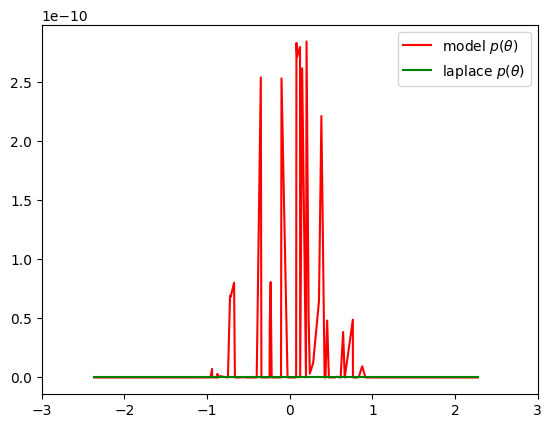

In [7]:
_, function_values_eval, weights_eval, posterior_samples_eval = integrator(sampler=laplace, model_func=make_functional_fwd_xs(UFA_model), xs=xs)

err = (function_values_eval[:,:, :]-ys).pow(2).sum(dim=[1,2])
log_prob = -err/(2 * tensify(target_sigma)**2) - ys.shape[0] * .5 * tensify(target_sigma) * torch.log(torch.tensor(2 * torch.pi)) 
val, ind = laplace.eps[:, 0][0:100].sort()
reg = log_prob[(laplace.eps[:, 0]**2).argmin()]
lp = torch.distributions.Normal(0,1).log_prob(laplace.eps[:, 0]) + reg - torch.distributions.Normal(0,1).log_prob(torch.tensor(0.0)) 
plt.plot(val.detach(), log_prob.exp()[ind].detach(), label="model $p(\\theta)$", c="r")
plt.plot(val.detach(), lp.exp()[ind].detach(), label="laplace $p(\\theta)$", c="g")
plt.legend()
plt.xlim(-3, 3)
#plt.savefig(os.path.join(fig_folder, "UFA_laplace_prob.png"))
plt.show()

In [8]:
val

tensor([-2.3663, -2.3549, -1.8547, -1.7193, -1.7126, -1.6994, -1.6271, -1.6230,
        -1.3707, -1.3043, -1.2943, -1.1864, -1.1122, -0.9875, -0.9587, -0.9396,
        -0.9375, -0.8766, -0.8736, -0.8653, -0.8378, -0.8199, -0.7475, -0.7219,
        -0.7147, -0.6731, -0.6632, -0.6430, -0.6257, -0.6115, -0.5577, -0.5190,
        -0.4818, -0.4238, -0.4041, -0.4002, -0.3995, -0.3496, -0.3425, -0.2950,
        -0.2611, -0.2439, -0.2437, -0.2416, -0.2309, -0.2182, -0.2144, -0.1050,
        -0.0995, -0.0263, -0.0203,  0.0117,  0.0199,  0.0775,  0.0813,  0.0891,
         0.1246,  0.1265,  0.1505,  0.1969,  0.2035,  0.2287,  0.2430,  0.2837,
         0.3539,  0.3831,  0.4219,  0.4325,  0.4528,  0.4738,  0.4850,  0.5321,
         0.5327,  0.5496,  0.5677,  0.6158,  0.6458,  0.6657,  0.7638,  0.7648,
         0.8143,  0.8352,  0.8767,  0.9160,  0.9184,  0.9972,  1.0942,  1.1459,
         1.1565,  1.1630,  1.2309,  1.2840,  1.4889,  1.5120,  1.5646,  1.5658,
         1.6147,  1.8631,  2.2502,  2.27

In [9]:
torch.manual_seed(0)
R_sampler = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma,  
                            n_posterior_samples=10, subspace_rank=2)
R_sampler.fit(fitting_type="GGN")
_=R_sampler.make_posterior_sample(n_samples=10)



 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la/riemann_sampler.py:50: UserWarning:The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3687.)


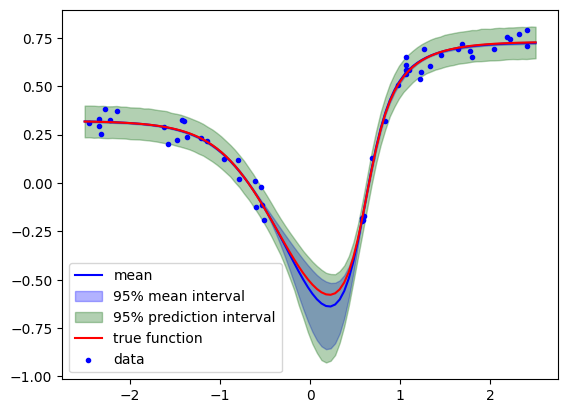

In [10]:
integral_riemann, function_values_riemann, weights_riemann, posterior_samples_riemann = integrator(R_sampler, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means_riemann = function_values_riemann.mean(dim=0).detach()
upper95_riemann = function_values_riemann.quantile(.95, dim=0).detach()
lower95_riemann = function_values_riemann.quantile(.05, dim=0).detach()
pred_samples_riemann = (torch.distributions.Normal(function_values_riemann, target_sigma).sample((1000,)))
upper95_both_riemann = (pred_samples_riemann.reshape(pred_samples_riemann.shape[0] * pred_samples_riemann.shape[1], *pred_samples_riemann.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_riemann = (pred_samples_riemann.reshape(pred_samples_riemann.shape[0] * pred_samples_riemann.shape[1], *pred_samples_riemann.shape[2:])).quantile(.05, dim=0).detach()


plt.plot(xs_plt, means_riemann, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_riemann[:,0], upper95_riemann[:,0], alpha=0.3, color="blue", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_riemann[:,0], upper95_both_riemann[:,0], alpha=0.3, color="darkgreen", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/UFA_riemannian_subspace_rank2.png")
plt.show()

# means = integral_riemann.detach()[:, 0]
# epistemic_var = (function_values_riemann[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
# aleatoric_var = target_sigma**2
# plt.plot(xs_plt, means, c="darkgreen", label="mean")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="blue", label="epistemic + aleatoric")
# plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="darkgreen", label="epistemic")
# plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# plt.legend()
# plt.savefig(os.path.join(fig_folder, "UFA_riemannian_subspace_rank1.png"))
# plt.show()

In [11]:
%%script echo
torch.manual_seed(0)
R_sampler = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma,  
                            n_posterior_samples=10, subspace_rank=0)
R_sampler.fit(fitting_type="GGN")
R_sampler.make_posterior_sample(n_samples=10)
#riemann_plotter(R_sampler)

integral, function_values, weights, posterior_samples = integrator(R_sampler, model_func=make_functional_fwd_xs(UFA_model), xs=xs_plt)

means = integral.detach()[:, 0]
epistemic_var = (function_values[:,:, 0]-means.unsqueeze(0)).pow(2).mean(dim=0).detach()
aleatoric_var = target_sigma**2
plt.plot(xs_plt, means, c="g", label="mean")
plt.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
plt.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
plt.legend()
plt.savefig(os.path.join(fig_folder, "UFA_riemannian_subspace_rank1.png"))
plt.show()

In [12]:
####################################
# Bayesian Quadrature integration
####################################

R_sampler_1d = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma, subspace_rank=1)
_=R_sampler_1d.fit(fitting_type="GGN")

BQ_1d = BayesianQuadrature_rays(R_sampler_1d, evaluation_model=UFA_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=False,  
                             use_rays=False, 
                             theta_space_plot_limits=[[-1,1], [-1,1]], xs = xs[0], parametersubset=None)

for i in range(2):
    integral_mean, integral_variance = BQ_1d.step()
    print(f"{i = }, observations = {BQ_1d.emukit_method.X.shape[0]}, {integral_mean = }, {integral_variance = }")


i = 0, observations = 2, integral_mean = tensor([0.5410]), integral_variance = tensor(0.0436)
i = 1, observations = 3, integral_mean = tensor([0.6411]), integral_variance = tensor(0.0025)


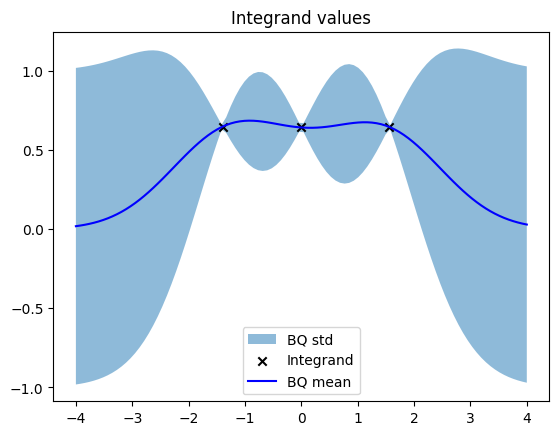

 /Users/simondanieleiriksson/Documents/DTU-kurser-lokalt/Specialkursus Georgios/riemannian-la/riemannian_la/BQ_rays_subspace.py:515: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


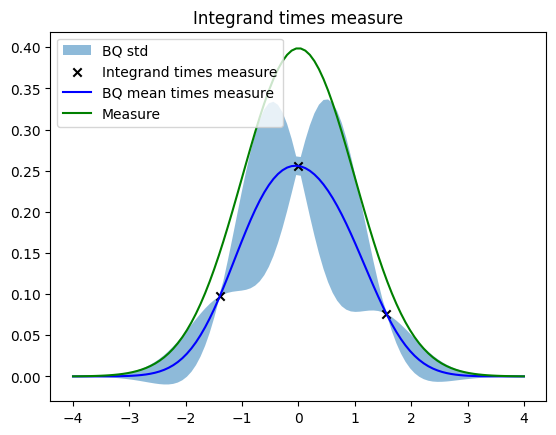

In [13]:
# fig, axes = plt.subplots(1,2, figsize=(10,5))
# BQ.plot_integrand_1d(ax=axes[0])
# BQ.plot_integrand_measure_1d(ax=axes[1])
# plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_1d.png"))
# plt.show()
fig, ax = plt.subplots(1,1)
BQ_1d.plot_integrand_1d(ax=ax)
plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_vals_1d.png"))
plt.show()

fig, ax = plt.subplots(1,1)
BQ_1d.plot_integrand_measure_1d(ax=ax)
plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_vals_measure_1d.png"))
plt.show()


In [18]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.distributions.multivariate_normal import _precision_to_scale_tril
from utils import tensify, loss_func_from_target_sigma, make_functional_fwd_xs, vector_to_parameterdict, make_functional_fwd, make_functional_fwd_vector_xs
from GGN_hessian import GGN_hessian_from_loader
from hessian import hessian_from_model_loss_and_data, hessian_dict_to_matrix, hessian_from_loader, hessian_from_func
from utils import NegLogLik_regression, NegLogLik_classification, iid_gaussian_prior_loss
from torch.func import grad, jvp, vjp, hessian, jacfwd, jacrev, vmap, functional_call
from laplace_approx import Laplace
from scipy.integrate import solve_ivp
from utils import make_functional_fwd_xs, functional_loss_for_vmap, neglog_loss, make_functional_fwd_vector, identity_func
from models import functional_banana, Model_from_func, functional_d1_halfcircle, functional_d1_2, functional_d1, functional_d1_fourth_degree_poly, LinearModel, functional_d1_normal
from matplotlib import pyplot as plt
from MCMC_sampler import MCMC_sampler
import torchdiffeq
import seaborn as sns
import pandas as pd
from riemann_sampler import Riemann_sampler, riemann_plotter

import GPy
from FullGaussianMeasure import FullGaussianMeasure
from emukit.model_wrappers.gpy_quadrature_wrappers import BaseGaussianProcessGPy, RBFGPy
from emukit.model_wrappers import GPyModelWrapper

from emukit.quadrature.kernels import QuadratureRBFLebesgueMeasure, QuadratureRBFGaussianMeasure, QuadratureRBF
from emukit.quadrature.measures import LebesgueMeasure, GaussianMeasure

from emukit.quadrature.methods import VanillaBayesianQuadrature, WarpedBayesianQuadratureModel, BoundedBayesianQuadrature
from emukit.quadrature.methods.warpings import SquareRootWarping, IdentityWarping
from emukit.quadrature.acquisitions import IntegralVarianceReduction
from emukit.core.optimization import GradientAcquisitionOptimizer
from emukit.core.parameter_space import ParameterSpace
from emukit.quadrature.interfaces.base_gp import IBaseGaussianProcess
from emukit.quadrature.kernels import GaussianEmbedding, LebesgueEmbedding, QuadratureKernel
from emukit.quadrature.interfaces.standard_kernels import IRBF

import numpy as np

from RayAcquisition import RayAcquisition

from typing import Tuple

import numpy as np



def reasonable_box_fixed(self_object, factor=4):
    def fn():
        lower = self_object.mean - factor * np.sqrt(self_object.variance)
        upper = self_object.mean + factor * np.sqrt(self_object.variance)
        return list(zip(lower, upper))
    return fn



def transform(type="sqrt", param=1):
    if type == "sqrt":
        def fn_forward(x):
            return (x).sqrt()
        def fn_backward(mus, vars):
            return [mus**2 + vars]
        
    elif type == "log":
        def fn_forward(x):
            return (x).log()
        def fn_backward(mus, vars):
            return [torch.exp(mus + .5*vars)]
        
    elif type == "softplus":
        def fn_forward(x):
            return (x+param).log()
        def fn_backward(mus, vars):
            return [(mus + 0.5*vars).exp()-param]
        
    elif type == "identity":
        def fn_forward(x):
            return x
        def fn_backward(mus, vars):
            return [mus, vars]
        
    elif type == "exp":
        def fn_forward(x):
            return x.exp()
        def fn_backward(mus, vars):
            return [mus.log()]

    elif type == "inv":
        def fn_forward(x):
            return 1/x
        def fn_backward(mus, vars):
            return [1/mus]
        
    elif type == "softexp":
        def fn_forward(x):
            return (x).exp()-param
        def fn_backward(mus, vars):
            return [(mus + vars*.5).exp()-param]
        
    elif type == "power":
        def fn_forward(x):
            return (x)**(param)
        def fn_backward(mus, vars):
            return [(mus**2)**(1/(param*2)) + .5*vars]

    return fn_forward, fn_backward

class VanillaBayesianQuadrature_multidim_output(WarpedBayesianQuadratureModel):
    def __init__(self, base_gp: IBaseGaussianProcess, X: np.ndarray, Y: np.ndarray):
        super(VanillaBayesianQuadrature_multidim_output, self).__init__(base_gp=base_gp, warping=IdentityWarping(), X=X, Y=Y)

    def predict_base(self, X_pred: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        m, cov = self.base_gp.predict(X_pred)
        return m, cov, m, cov

    def predict_base_with_full_covariance(self, X_pred: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        m, cov = self.base_gp.predict_with_full_covariance(X_pred)
        return m, cov, m, cov

    def integrate(self) -> Tuple[float, float]:
        kernel_mean_X = self.base_gp.kern.qK(self.X)
        integral_mean = np.dot(kernel_mean_X, self.base_gp.graminv_residual())[0, :]
        integral_var = self.base_gp.kern.qKq() - (kernel_mean_X @ self.base_gp.solve_linear(kernel_mean_X.T))[0, 0]
        return integral_mean, integral_var

    def get_prediction_gradients(self, X: np.ndarray) -> Tuple:
        return self.base_gp.get_prediction_gradients(X)


class BayesianQuadrature_rays():
    def __init__(self, Rsampler: Riemann_sampler, evaluation_model=None, measure="gaussian_rescaled", 
                 integral_bounds_std=2, GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=10, 
                 use_ray_acqusition=True, use_rays=True,
                 square_plots=True, theta_space_plot_limits=None, xs=None, parametersubset=None, output_func=identity_func, device="cpu", contour_fill="Grey", contour_linewidth=.1):
        self.contour_linewidth = contour_linewidth
        self.contour_fill = contour_fill
        self.device=device
        self.Rsampler = Rsampler
        self.evaluation_model = evaluation_model
        self.measure = measure
        self.integral_bounds_std = integral_bounds_std
        self.GP_lengthscale = GP_lengthscale
        self.GP_variance = GP_variance
        self.theta_space_plot_limits = theta_space_plot_limits
        if parametersubset is None:
            self.parametersubset = dict(evaluation_model.named_parameters())
        else:
            self.parametersubset = parametersubset


        self.output_func = output_func
        self.functional_fwd = make_functional_fwd_vector(evaluation_model, xs, parametersubset=self.parametersubset, output_func=output_func)
        self.functional_fwd_xs = make_functional_fwd_xs(evaluation_model, output_func=output_func)

        self.num_timesteps = num_timesteps
        self.square_plots = square_plots

        if measure=="gaussian_rescaled":
            self.integrand = self.gaussian_integrand_rescaled
            self.measure_rescaled = True
            self.measure_type = "gaussian"

        elif measure == "lebesgue":
            self.integrand = self.lebesgue_integrand
            self.measure_rescaled = False
            self.measure_type = "lebesgue"

        elif measure == "lebesgue_rescaled":
            self.integrand = self.lebesgue_integrand_rescale
            self.measure_rescaled = True
            self.measure_type = "lebesgue"

        #self.v_init = torch.zeros(self.Rsampler.num_params)
        #self.model_output_init = self.y.unsqueeze(0).detach().numpy()
        self.sampling_dims = self.Rsampler.subspace_rank
        self.v_init = torch.zeros((self.sampling_dims), dtype=torch.float32).to(self.device)
        self.y_init, self.theta_init = self.integrand(self.v_init)
        self.y_init, self.theta_init = self.y_init[0,:], self.theta_init[0,:]
        
        #self.vs = np.expand_dims(self.v_init, 0)
        self.vs = self.v_init.unsqueeze(0)
        self.vs_ray = self.vs
        #self.integrand_values = np.expand_dims(self.y_init, 0)
        self.integrand_values = self.y_init.unsqueeze(0)
        #self.thetas = np.expand_dims(self.theta_init, 0)
        self.thetas = self.theta_init.unsqueeze(0)
        self.steps = 0


    # GPy takes X and Y values at initialization. Those will be overwritten later when the emukit model is initialized.
        self.BQ_kernel = kernel=GPy.kern.RBF(
                                    input_dim=self.sampling_dims, 
                                    lengthscale=self.GP_lengthscale,
                                    variance=self.GP_variance)
        #print(f"{self.vs.shape = }, {self.integrand_values.shape = }")
        self.gpy_model = GPy.models.GPRegression(X=self.vs_ray.detach().cpu().numpy(), 
                                                 Y=self.integrand_values.detach().cpu().numpy(), 
                                                 kernel=self.BQ_kernel)
        self.emukit_rbf = RBFGPy(self.gpy_model.kern)

        if self.measure_rescaled:
            self.limits = self.integral_bounds_std * torch.ones(self.sampling_dims).to(self.device) # use dimensionality of the subspace model
            self.plot_limits = self.integral_bounds_std * torch.ones(self.Rsampler.num_params).to(self.device) # use dimensionality of the full model

        elif not self.measure_rescaled:
            # set the limits for the integration bounds to the standard deviation of the laplace approximation times some number.
            if self.Rsampler.is_subspacelaplace:
                scaling = self.Rsampler.svd_S[:self.sampling_dims].sqrt() # use dimensionality of the subspace model
                # perhaps this works?
            else:
                scaling  = np.sqrt(torch.diag(self.Rsampler.covariance)) # use dimensionality of the full model
            self.limits = self.integral_bounds_std * scaling # use dimensionality of the sampling space (full or subspace)
            self.plot_limits = self.integral_bounds_std * torch.sqrt(torch.diag(self.Rsampler.covariance)[-self.sampling_dims:])  # use dimensionality of the subspace model
        if self.square_plots:
            self.plot_limits = self.plot_limits.max() * torch.ones_like(self.plot_limits).to(self.device)

        if self.measure_type=="gaussian":
            self.emukit_measure = GaussianMeasure(mean=np.zeros(self.sampling_dims), 
                                              variance=np.ones(self.sampling_dims))
            self.emukit_measure.reasonable_box = reasonable_box_fixed(self.emukit_measure, factor=self.integral_bounds_std)
            self.emukit_qrbf = QuadratureRBFGaussianMeasure(self.emukit_rbf, self.emukit_measure)
            self.plt_measure_dist = torch.distributions.MultivariateNormal(torch.zeros(self.sampling_dims), torch.eye(self.sampling_dims))

        if self.measure_type=="lebesgue":
            #print(f"{self.limits = }")
            #print(f"{self.plot_limits = }")
            limits_list_of_lists = [[-l, l] for l in self.limits]
            self.emukit_measure = LebesgueMeasure.from_bounds(limits_list_of_lists)
            self.emukit_qrbf = QuadratureRBFLebesgueMeasure(self.emukit_rbf, self.emukit_measure)
            self.plt_measure_dist = torch.distributions.Uniform(-self.plot_limits, self.plot_limits)
            self.plt_measure_dist.log_prob = lambda z: -torch.log((torch.tensor(self.plot_limits) * 2).prod()).repeat(z.shape[0])

        self.emukit_model = BaseGaussianProcessGPy(kern=self.emukit_qrbf, gpy_model=self.gpy_model)
        #self.emukit_method = VanillaBayesianQuadrature(base_gp=self.emukit_model, X=self.vs[0:1], Y=self.integrand_values[0:1])
        #print(f"{self.vs_ray.shape = }, {self.integrand_values.shape = }")
        self.emukit_method = VanillaBayesianQuadrature_multidim_output(base_gp=self.emukit_model, X=self.vs_ray.detach().cpu().numpy(), Y=self.integrand_values.detach().cpu().numpy())
        if use_ray_acqusition:
            self.ivr_acquisition = RayAcquisition(self.emukit_method, self.v_init.detach().cpu().numpy(), self.num_timesteps)
        else:
            self.ivr_acquisition = IntegralVarianceReduction(self.emukit_method)

        self.space = ParameterSpace(self.emukit_method.reasonable_box_bounds.convert_to_list_of_continuous_parameters())
        self.optimizer = GradientAcquisitionOptimizer(self.space)
        self.has_plotted = False
        self.use_rays = use_rays
        self.plot_N_mesh=100
        
    def step(self):
        v_new, acq_val = self.optimizer.optimize(self.ivr_acquisition)
        #print(f"{(v_new**2).sum() = }, {acq_val = }")
        v_new_t = torch.tensor(v_new).to(torch.float32).to(self.device)
        #print(f"{v_new = }")
        #print(f"{self.vs = }")
        self.vs = torch.cat([self.vs, v_new_t], dim=0)
        self.ys_new, thetas_new = self.integrand(v_new_t.squeeze(0))
        #print(f"{self.ys_new = }, {thetas_new = }")

        if self.use_rays:
            use_index = range(1, self.num_timesteps)
        else:
            use_index = [self.num_timesteps-1]
        #print(f"{use_index = }")
        #print(f"{thetas_new.shape = }")
        #print(f"{thetas_new[use_index].shape = }")
        self.thetas = torch.cat([self.thetas, thetas_new[use_index]], dim=0)
    
        spacing = torch.linspace(0, 1, self.num_timesteps, device=self.device).unsqueeze(-1)
        #vs_ray_new = np.linspace(self.v_init, v_new[0], self.num_timesteps)
        vs_ray_new = self.v_init + spacing * (v_new_t - self.v_init)
        self.vs_ray = torch.cat([self.vs_ray, vs_ray_new[use_index]], dim=0)
        
        self.integrand_values = torch.cat([self.integrand_values, self.ys_new[use_index]], dim=0)
        self.emukit_method.set_data(self.vs_ray.detach().cpu().numpy(), self.integrand_values.detach().cpu().numpy())
        integral_mean, integral_variance = self.emukit_method.integrate()
        self.integral_mean, self.integral_variance = torch.tensor(integral_mean, device=self.device, dtype=torch.float32), torch.tensor(integral_variance, device=self.device, dtype=torch.float32)
        self.steps += 1
        return self.integral_mean, self.integral_variance

    def lebesgue_integrand(self, v):
        num_ts = self.num_timesteps
        res, ts = self.Rsampler.expmap_torchdiffeq(self.Rsampler.mean, self.Rsampler.scale @ v, num_ts=num_ts)
        thetas = res[:,:self.Rsampler.num_params]
        vs_ray = torch.tensor(np.linspace(self.v_init, v.detach().numpy(), self.num_timesteps))
        v_dist = torch.distributions.MultivariateNormal(torch.zeros(self.sampling_dims), torch.eye(self.sampling_dims))
        #ys = torch.stack([self.functional_fwd(theta) * self.Rsampler.posterior_logprob(vs_ray[i]).exp() for i, theta in enumerate(thetas)])
        #print(f"{vs_ray = }, {thetas = }")
        ys = torch.stack([self.functional_fwd(theta) * v_dist.log_prob(vs_ray[i]).exp() for i, theta in enumerate(thetas)])
        #return self.functional_fwd(theta) * R_sampler.posterior_logprob(v).exp(), theta
        return ys, thetas

    def lebesgue_integrand_rescale(self, z):
        num_ts = self.num_timesteps
        g = lambda z: self.Rsampler.scale @ z
        v = g(z)
        res, ts = self.Rsampler.expmap_torchdiffeq(self.Rsampler.mean, v, num_ts=num_ts)
        #vs_ray = torch.tensor(np.linspace(self.v_init, v.detach().numpy(), self.num_timesteps))
        z_init = np.zeros(self.sampling_dims)
        zs_ray = torch.tensor(np.linspace(z_init, z.detach().numpy(), self.num_timesteps))
        #print(f"{vs_ray.shape = }, {zs_ray.shape = }")
        #zs_ray = torch.stack([g_inv(v) for v in vs_ray])
        #theta = res[-1,:self.Rsampler.num_params].T
        thetas = res[:,:self.Rsampler.num_params]
        z_dist = torch.distributions.MultivariateNormal(torch.zeros(self.sampling_dims), torch.eye(self.sampling_dims))
        ys = torch.stack([self.functional_fwd(theta) * z_dist.log_prob(zs_ray[i]).exp() for i, theta in enumerate(thetas)])
        #print(f"{ys.shape = }, {thetas.shape = }")
        return ys, thetas

    def gaussian_integrand_rescaled(self, z):
        num_ts = self.num_timesteps
        g = lambda z: self.Rsampler.scale @ z
        v = g(z)
        res, ts = self.Rsampler.expmap_torchdiffeq(self.Rsampler.mean, v, num_ts=num_ts)
        thetas = res[:,:self.Rsampler.num_params]
        ys = torch.stack([self.functional_fwd(theta) for theta in thetas])
        return ys, thetas

    def predict_samples(self, xs):
        # returns a tensor with one row per parameter sample (theta) and then their correpsonding predictions for each x
        for i, theta in enumerate(self.thetas):
            params = vector_to_parameterdict(torch.tensor(theta, dtype=torch.float32), self.parametersubset)
            pred = self.functional_fwd_xs(params, xs)
            if i == 0:
                preds = torch.zeros((len(self.thetas), *pred.shape))
            preds[i] = pred
        return preds.permute(1,0,2)
    
    def pred_BQ_samples(self, xs, n_samples=100):
        preds = self.predict_samples(xs)
        X_bck = self.emukit_method.X # X here, is theta (for improved confusion / unreadability).
        Y_bck = self.emukit_method.Y

        # sample z's to evaluate GP in
        eps = torch.randn(n_samples, self.Rsampler.subspace_rank)

        # loop over each x and prediction(x)
        y_samples = torch.zeros((preds.shape[0], n_samples, preds.shape[2]), device=self.device)
        for i, pred in enumerate(preds):
            self.emukit_method.set_data(self.vs_ray.cpu().detach().numpy(), pred.cpu().detach().numpy()) # we have for each value of theta some values of pred(x)
            m, v = self.emukit_model.predict(eps.detach().numpy())
            y_samples[i] = torch.tensor(m, dtype=torch.float32, device=self.device)

        self.emukit_method.set_data(X_bck, Y_bck)
        return y_samples

    def pred_BQ(self, xs, get_mean=True, get_var=True, get_measure_variance=False, transform_type = "power", transform_param=2):
        preds = self.predict_samples(xs)
        X_bck = self.emukit_method.X # X here, is = z (for improved confusion / unreadability).
        Y_bck = self.emukit_method.Y

        # get means
        # loop over each x and prediction(x)
        for i, pred in enumerate(preds):
            self.emukit_method.set_data(self.vs_ray, pred) #we have for each value of theta some values of pred(x)
            mu, var = self.emukit_method.integrate() # integrate the function pred(theta given x)
            if i == 0:
                first_moments_mus = torch.zeros((len(preds), *mu.shape))
                first_moments_vars = torch.zeros((len(preds), *var.shape))
            first_moments_mus[i] = tensify(mu)
            first_moments_vars[i] = tensify(var)
        
        forward_transform, backwards_transform = transform(transform_type, param=transform_param)

        # get second moment
        for i, pred in enumerate(preds):
            sqr_error = (preds[i] -first_moments_mus.unsqueeze(1)[i])**2
            self.emukit_method.set_data(self.vs_ray, forward_transform(sqr_error))
            mu, var = self.emukit_method.integrate()
            #emukit_method = VanillaBayesianQuadrature(base_gp=self.emukit_model, X=self.vs_ray, Y=forward_transform(sqr_error))
            #mu, var = emukit_method.integrate()
            if i == 0:
                central_second_moment_mus = torch.zeros((len(preds), *mu.shape))
                central_second_moment_vars = torch.zeros((len(preds), *var.shape))
            trans = backwards_transform(torch.tensor(mu), torch.tensor(var))
            central_second_moment_mus[i] = trans[0]
            if len(trans) == 2: 
                central_second_moment_vars[i] = trans[1]
        
        self.emukit_method.set_data(X_bck, Y_bck)

        vars = [first_moments_vars]
        if len(trans)==2: vars += [central_second_moment_vars]

        returns = []
        if get_mean:
            returns += [first_moments_mus]
        if get_var:
            returns += [central_second_moment_mus]
        if get_measure_variance:
            returns += [vars]
        return returns

    def plot_integrand_2d(self, ax=None):
        # plot integrand values
        ax.scatter(self.vs_ray[:,0], self.vs_ray[:,1], c=self.integrand_values, cmap=self.contour_fill)
        ax.set_title("Integrand values")
        ax.set_xlim(-self.plot_limits[0], self.plot_limits[0])
        ax.set_ylim(-self.plot_limits[1], self.plot_limits[1])
        
    def plot_integrand_measure_2d(self, ax=None):
        ax.scatter(self.vs_ray[:,0], self.vs_ray[:,1], 
                    c=self.integrand_values[:,0] * self.plt_measure_dist.log_prob(torch.tensor(self.vs_ray)).exp().detach().numpy(), 
                    cmap=self.contour_fill)
        ax.set_title("Integrand values times measure")
        ax.set_xlim(-self.plot_limits[0], self.plot_limits[0])
        ax.set_ylim(-self.plot_limits[1], self.plot_limits[1])

    def plt_BQ_mean_2d(self, ax=None):
        self.plot_init_2d()
        mu_plot, var_plot = self.emukit_method.predict(self.xys_plt)
        ax.contourf(self.xs_plt, self.ys_plt, mu_plot.reshape(self.plot_N_mesh, self.plot_N_mesh).T, cmap=self.contour_fill)
        ax.contour(self.xs_plt, self.ys_plt, mu_plot.reshape(self.plot_N_mesh, self.plot_N_mesh).T, colors="black", linewidths=self.contour_linewidth)

        ax.scatter(self.vs_ray[:,0], self.vs_ray[:,1], c="k", marker="x")
        ax.set_title("BQ Model mean")
        ax.set_xlim(-self.plot_limits[0], self.plot_limits[0])
        ax.set_ylim(-self.plot_limits[1], self.plot_limits[1])
    
    def plot_BQ_mean_measure_2d(self, ax=None):
        self.plot_init_2d()
        mu_plot, var_plot = self.emukit_method.predict(self.xys_plt)
        ax.contourf(self.xs_plt, self.ys_plt, mu_plot.reshape(self.plot_N_mesh,self.plot_N_mesh).T * self.plt_measure_dist.log_prob(torch.tensor(self.xys_plt.reshape(self.plot_N_mesh, self.plot_N_mesh, -1))).exp().detach().numpy(), cmap=self.contour_fill)
        ax.contour(self.xs_plt, self.ys_plt, mu_plot.reshape(self.plot_N_mesh,self.plot_N_mesh).T * self.plt_measure_dist.log_prob(torch.tensor(self.xys_plt.reshape(self.plot_N_mesh, self.plot_N_mesh, -1))).exp().detach().numpy(), colors="black", linewidths=.1)
        
        ax.scatter(self.vs_ray[:,0], self.vs_ray[:,1], c="k", marker="x")
        ax.set_title("BQ Model mean times measure")

    def plot_BQ_std_2d(self, ax=None):
        self.plot_init_2d()
        mu_plot, var_plot = self.emukit_method.predict(self.xys_plt)
        ax.contourf(self.xs_plt, self.ys_plt, np.sqrt(var_plot).reshape(self.plot_N_mesh,self.plot_N_mesh).T, cmap=self.contour_fill)
        ax.contour(self.xs_plt, self.ys_plt, np.sqrt(var_plot).reshape(self.plot_N_mesh,self.plot_N_mesh).T, colors="black", linewidths=self.contour_linewidth)
        ax.scatter(self.vs_ray[:,0], self.vs_ray[:,1], c="k", marker="x")
        #axes[3].scatter(xys_plt[:,0], xys_plt[:,1], c=np.sqrt(var_plot), cmap="Wistia")
        ax.set_title("BQ Model std")

    def plot_acquisition_2d(self, ax=None):
        self.plot_init_2d()
        squared_correlation, integral_current_var, y_predictive_var, predictive_cov = self.ivr_acquisition._evaluate(self.xys_plt)
        ax.contourf(self.xs_plt, self.ys_plt, np.sqrt(squared_correlation).reshape(self.plot_N_mesh,self.plot_N_mesh).T, cmap=self.contour_fill)
        ax.contour(self.xs_plt, self.ys_plt, np.sqrt(squared_correlation).reshape(self.plot_N_mesh,self.plot_N_mesh).T, colors="black", linewidths=self.contour_linewidth)
        ax.scatter(self.vs_ray[:,0], self.vs_ray[:,1], c="k", marker="x")
        ax.set_title("Acquisition function")

    def plot_true_function_likelihood_2d(self, ax=None):
        self.plot_init_2d()
        self.get_funcvals()
        ax.contourf(self.xs_plt, self.ys_plt, self.function_times_likelihood.detach(), cmap=self.contour_fill)
        ax.scatter(self.thetas[:,0] - self.Rsampler.mean[0].detach().numpy(), self.thetas[:,1] - self.Rsampler.mean[1].detach().numpy(), c="k", marker="x")
        
        rays = self.thetas[1:].reshape(-1, self.num_timesteps-1, 2).permute(0, 2, 1)
        rays2 = np.concatenate([np.tile(self.thetas[None, 0, None].permute(0, 2, 1), [rays.shape[0],1,1]), rays] , axis=2)

        for i, sample in enumerate(rays2):
            ax.plot(sample[0]-self.Rsampler.mean[0].detach().numpy(), 
                    sample[1]-self.Rsampler.mean[1].detach().numpy(), marker=None, c="k", alpha=0.3)

        ax.set_title("True function times model likelihood")
        ax.set_xlim(-self.plot_limits[0], self.plot_limits[0])
        ax.set_ylim(-self.plot_limits[1], self.plot_limits[1])
        if self.theta_space_plot_limits is not None:
            ax.set_xlim(self.theta_space_plot_limits[0])
            ax.set_ylim(self.theta_space_plot_limits[1])


    def plot_model_likelihood_2d(self, ax=None, function_vals = True):
        self.plot_init_2d()
        self.get_funcvals()
        ax.contourf(self.xs_plt, self.ys_plt, (-self.plt_model_loss*2).exp().detach(), cmap=self.contour_fill)
        ax.contour(self.xs_plt, self.ys_plt, (-self.plt_model_loss*2).exp().detach(), colors="black", linewidths=self.contour_linewidth)
        
        if function_vals:
            ax.contour(self.xs_plt, self.ys_plt, self.function_vals.detach(), cmap="Grays")
        
        ax.scatter(self.thetas[:,0] - self.Rsampler.mean[0].detach().numpy(), self.thetas[:,1] - self.Rsampler.mean[1].detach().numpy(), c="k", marker="x")

        rays = self.thetas[1:].reshape(-1, self.num_timesteps-1, 2).permute(0, 2, 1)
        rays2 = np.concatenate([np.tile(self.thetas[None, 0, None].permute(0, 2, 1), [rays.shape[0],1,1]), rays] , axis=2)

        for i, sample in enumerate(rays2):
            ax.plot(sample[0]-self.Rsampler.mean[0].detach().numpy(), 
                    sample[1]-self.Rsampler.mean[1].detach().numpy(), marker=None, c="k", alpha=0.3)


        #axes[0][3].contour(self.xs_plt, self.ys_plt, self.function_vals.detach(), c="k")
        ax.set_title("Model loss and true function values")
        ax.set_xlim(-self.plot_limits[0], self.plot_limits[0])
        ax.set_ylim(-self.plot_limits[1], self.plot_limits[1])
        if self.theta_space_plot_limits is not None:
            ax.set_xlim(self.theta_space_plot_limits[0])
            ax.set_ylim(self.theta_space_plot_limits[1])


    def plot_init_2d(self):
        if not self.has_plotted:
            self.xs_plt = np.linspace(-self.plot_limits[0], self.plot_limits[0], self.plot_N_mesh)
            self.ys_plt = np.linspace(-self.plot_limits[1], self.plot_limits[1], self.plot_N_mesh)
            self.xys_plt = np.array([[x, y] for x in self.xs_plt for y in self.ys_plt])
    
    def get_funcvals(self):
        if not self.has_plotted:
            self.function_vals = torch.stack([self.functional_fwd(obs + self.Rsampler.mean) for obs in torch.tensor(self.xys_plt, dtype=torch.float32)]).reshape(self.plot_N_mesh, self.plot_N_mesh).T
            #f_model = make_functional_fwd_vector(self.Rsampler.model, self.xs, parametersubset=dict(self.Rsampler.model.named_parameters()))
            #f_model = make_functional_fwd_xs(self.Rsampler.model)
            #self.f_loss = functional_loss_for_vmap(f_model, self.Rsampler.parametersubset, self.Rsampler.loss_fn, self.Rsampler.xs, self.Rsampler.ys, prior_logprob=self.Rsampler.prior_logprob)
            
            self.plt_model_loss = torch.stack([self.Rsampler.f_loss(obs + self.Rsampler.mean) for obs in torch.tensor(self.xys_plt, dtype=torch.float32)]).reshape(self.plot_N_mesh, self.plot_N_mesh).T
            self.function_times_likelihood = self.function_vals * (-self.plt_model_loss).exp()


    def plot_integrand_measure_1d(self, ax=None):
        xs_plt = np.linspace(-self.limits, self.limits, 100)
        mu_plot, var_plot = self.emukit_method.predict(xs_plt)

        # plot BQ model mean times measure
        plt_measure = self.plt_measure_dist.log_prob(torch.tensor(xs_plt)).exp().detach().numpy()
        plt_measure_points = self.plt_measure_dist.log_prob(torch.tensor(self.vs_ray)).exp().detach().numpy()
        ax.fill_between(xs_plt[:,0], (mu_plot - np.sqrt(var_plot))[:,0]* plt_measure, (mu_plot + np.sqrt(var_plot))[:,0]* plt_measure, alpha=0.5, label="BQ std")
        ax.scatter(self.vs_ray[:,0], self.integrand_values[:,0] * plt_measure_points , c="k", marker="x", label="Integrand times measure")
        ax.plot(xs_plt[:,0], mu_plot[:,0] * plt_measure, label="BQ mean times measure", c="b")
        ax.plot(xs_plt[:,0], plt_measure, label="Measure", c="g")
        ax.set_title("Integrand times measure")
        ax.legend()

    def plot_integrand_1d(self, ax=None):
        self.plot_init_1d()
        # plot integrand values
        xs_plt = np.linspace(-self.limits, self.limits, self.plot_N_mesh)
        mu_plot, var_plot = self.emukit_method.predict(xs_plt)
        ax.fill_between(xs_plt[:,0], (mu_plot - np.sqrt(var_plot))[:,0], (mu_plot + np.sqrt(var_plot))[:,0], alpha=0.5, label="BQ std")
        ax.scatter(self.vs_ray[:,0], self.integrand_values, c="k", marker="x", label="Integrand")
        ax.plot(xs_plt, mu_plot, label="BQ mean", c="b")
        ax.set_title("Integrand values")
        #ax.set_xlim(-self.limits[0], self.limits[0])
        #ax.set_ylim(self.plt_1d_ylimit[0], self.plt_1d_ylimit[1])
        ax.legend()

    def plot_true_function_likelihood_1d(self, ax=None):
        self.plot_init_1d()
        ax.plot(self.xs_plt_1d[:,0], self.function_times_likelihood.detach().numpy(), label="True function times model likelihood")
        ax.plot(self.xs_plt_1d[:,0], self.function_vals.detach().numpy(), label="True function")
        ax.plot(self.xs_plt_1d[:,0], self.plt_likelihood.detach().numpy(), label="Model likelihood")

        ax.scatter(self.thetas[:,0] - self.Rsampler.mean[0].detach().numpy(), self.integrand_values, c="k", marker="x", label="Integrand")
        ax.set_title("True function times model likelihood")
        ax.set_xlim(-self.limits, self.limits)
        ax.set_ylim(min(self.function_times_likelihood.nan_to_num(posinf=10).min().detach(), self.integrand_values.min()), 
                    max(self.function_times_likelihood.nan_to_num(posinf=10).max().detach(), self.integrand_values.max()) 
                    )
        ax.set_ylim(0,.5)
        if self.theta_space_plot_limits is not None:
            ax.set_xlim(self.theta_space_plot_limits)
        ax.legend()

    def plot_init_1d(self):
        self.plt_1d_ylimit = [self.integrand_values.min(), self.integrand_values.max()]
        self.xs_plt_1d = np.linspace(-self.limits, self.limits, self.plot_N_mesh)
        self.function_vals = torch.stack([self.functional_fwd(obs + self.Rsampler.mean) for obs in torch.tensor(self.xs_plt_1d, dtype=torch.float32)]).reshape(self.plot_N_mesh)
        self.plt_model_loss = torch.stack([self.Rsampler.f_loss(obs + self.Rsampler.mean) for obs in torch.tensor(self.xs_plt_1d, dtype=torch.float32)])
        self.plt_likelihood = (-self.plt_model_loss).exp()
        self.function_times_likelihood = self.function_vals * self.plt_likelihood
       
    def plot(self):
        if self.Rsampler.num_params == 2 and self.sampling_dims == 2: # This is the case where we have 2d parameters and 2d subspace
            fig, axes = plt.subplots(2,4, figsize=(20,10))
            self.plot_integrand_2d(ax=axes[0][0])
            self.plot_integrand_measure_2d(ax=axes[1][0])
            self.plt_BQ_mean_2d(ax=axes[0][1])
            self.plot_BQ_mean_measure_2d(ax=axes[1][1])
            self.plot_model_likelihood_2d(ax=axes[0][2])
            self.plot_true_function_likelihood_2d(ax=axes[1][2])
            self.plot_BQ_std_2d(ax=axes[0][3])
            self.plot_acquisition_2d(ax=axes[1][3])
            self.has_plotted = True
            return fig, axes

        if self.Rsampler.num_params not in  [1,2] and self.sampling_dims == 2: # This is the case where we have >2d parameters and 2d subspace
            fig, axes = plt.subplots(2,3, figsize=(15,10))
            self.plot_integrand_2d(ax=axes[0][0])
            self.plot_integrand_measure_2d(ax=axes[0][1])
            self.plt_BQ_mean_2d(ax=axes[1][0])
            self.plot_BQ_mean_measure_2d(ax=axes[1][1])
            self.plot_BQ_std_2d(ax=axes[1][2])
            self.plot_acquisition_2d(ax=axes[0][2])
            self.has_plotted = True
            return fig, axes


        elif self.Rsampler.num_params == 2 and self.sampling_dims == 1: # This is the case where we have 2d parameters and 1d subspace
            fig, axes = plt.subplots(1,4, figsize=(15,5))
            self.plot_integrand_1d(ax=axes[0])
            self.plot_integrand_measure_1d(ax=axes[1])
            self.plot_true_function_likelihood_2d(ax=axes[2])
            self.plot_model_likelihood_2d(ax=axes[3])
            return fig, axes

        elif self.Rsampler.num_params == 1 and self.sampling_dims == 1: # This is the case where we have 1d parameters and 1d subspace
            fig, axes = plt.subplots(1,3, figsize=(15,5))
            self.plot_integrand_1d(ax=axes[0])
            self.plot_integrand_measure_1d(ax=axes[1])
            self.plot_true_function_likelihood_1d(ax=axes[2])
            return fig, axes



In [20]:
R_sampler_2d = Riemann_sampler(UFA_model, xs=xs, ys=ys, loss_fn=loss_fn, prior_sigma=prior_sigma, subspace_rank=2)
_=R_sampler_2d.fit(fitting_type="GGN")

BQ_2d = BayesianQuadrature_rays(R_sampler_2d, evaluation_model=UFA_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=True,  
                             use_rays=True, 
                             theta_space_plot_limits=[[-1,1], [-1,1]], xs = xs[0], parametersubset=None, contour_fill="Blues")

for i in range(16):
    integral_mean, integral_variance = BQ_2d.step()
    print(f"{i = }, observations = {BQ_2d.emukit_method.X.shape[0]}, {integral_mean = }, {integral_variance = }")
    if i == 8:
        fig, axes = BQ_2d.plot()
        plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_2d.png"))
        plt.show()


i = 0, observations = 7, integral_mean = tensor([0.4360]), integral_variance = tensor(0.0499)
i = 1, observations = 13, integral_mean = tensor([0.5671]), integral_variance = tensor(0.0167)
i = 2, observations = 19, integral_mean = tensor([0.5211]), integral_variance = tensor(0.0111)
i = 3, observations = 25, integral_mean = tensor([0.5779]), integral_variance = tensor(0.0060)


 /var/folders/t_/nfzp77bj23v7ypcy679dgp_80000gn/T/ipykernel_93506/1239116673.py:400: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


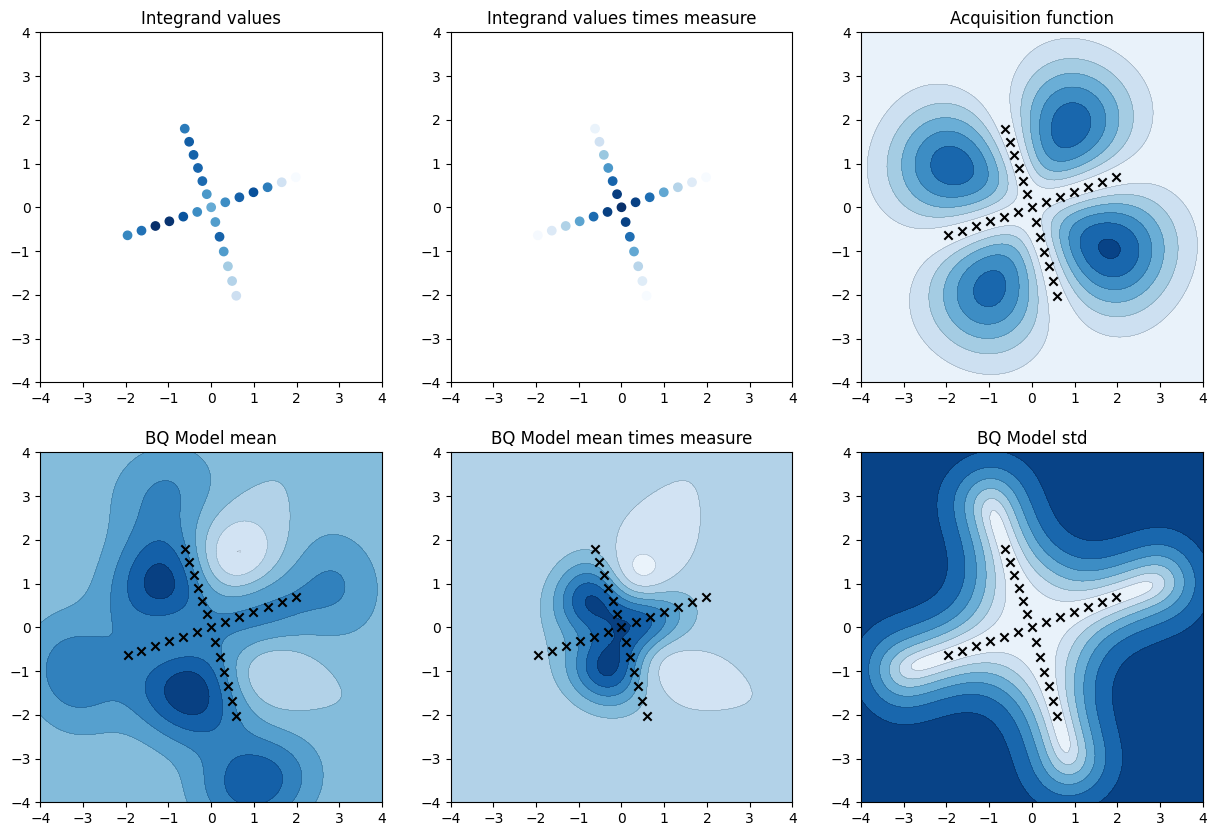

In [22]:
BQ_2d.contour_fill="Blues"
fig, axes = BQ_2d.plot()
plt.savefig(os.path.join(fig_folder, "UFA_BQ_integrand_2d.png"))
plt.show()

In [23]:
BQ_samp_trans = torch.tensor(BQ_2d.pred_BQ_samples(xs_plt, 1000))
BQ_samp_trans_mean = BQ_samp_trans.mean(dim=1)
upper95_riemann_BQ = BQ_samp_trans.quantile(.95, dim=1)
lower95_riemann_BQ = BQ_samp_trans.quantile(.05, dim=1)
pred_samples_riemann_BQ = torch.distributions.Normal(BQ_samp_trans, target_sigma).sample((17,)).permute(0,2,1,3)
upper95_both_riemann_BQ = (pred_samples_riemann_BQ.reshape(pred_samples_riemann_BQ.shape[0] * pred_samples_riemann_BQ.shape[1], *pred_samples_riemann_BQ.shape[2:])).quantile(.95, dim=0).detach()
lower95_both_riemann_BQ = (pred_samples_riemann_BQ.reshape(pred_samples_riemann_BQ.shape[0] * pred_samples_riemann_BQ.shape[1], *pred_samples_riemann_BQ.shape[2:])).quantile(.05, dim=0).detach()



 /var/folders/t_/nfzp77bj23v7ypcy679dgp_80000gn/T/ipykernel_93506/1239116673.py:319: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
 /var/folders/t_/nfzp77bj23v7ypcy679dgp_80000gn/T/ipykernel_93506/1024040591.py:1: UserWarning:To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


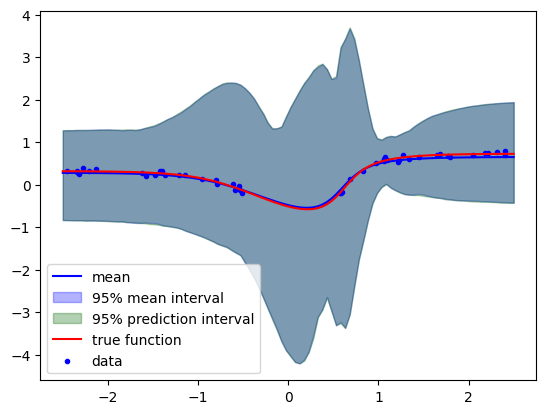

In [25]:
plt.plot(xs_plt, BQ_samp_trans_mean, c="blue", label="mean")
plt.fill_between(xs_plt[:,0], lower95_riemann_BQ[:,0], upper95_riemann_BQ[:,0], alpha=0.3, color="blue", label="95% mean interval")
plt.fill_between(xs_plt[:,0], lower95_both_riemann_BQ[:,0], upper95_both_riemann_BQ[:,0], alpha=0.3, color="darkgreen", label="95% prediction interval")
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
plt.legend()
plt.savefig(f"{fig_folder}/UFA_riemannian_BQ_subspace_rank2.png")
plt.show()

#means, epistemic_var, vars = BQ_2d.pred_BQ(xs_plt, get_measure_variance=True, transform_type="identity")
#plt.scatter(xs_plt.unsqueeze(1).repeat([1, preds.shape[1], 1]), preds, marker="x", c="y", label="second central moment")
#plt.scatter(xs_plt, second_central_moments_mus - first_central_moments_mus**2, marker="x", c="g", label="first central moment")
# fig, ax = plt.subplots(1,1)

# ax.plot(xs_plt, means, c="g", label="mean")
# ax.fill_between(xs_plt[:,0], means - np.sqrt(aleatoric_var + epistemic_var), means + np.sqrt(aleatoric_var + epistemic_var), alpha=0.3, color="darkgreen", label="epistemic + aleatoric")
# ax.fill_between(xs_plt[:,0], means - np.sqrt(epistemic_var), means + np.sqrt(epistemic_var), alpha=0.3, color="blue", label="epistemic")
# ax.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="r", label="true function")
# ax.scatter(xs[:, 0].detach(), ys.detach(), c="b", marker=".", label="data")
# ax.legend()x
# plt.savefig(os.path.join(fig_folder, "UFA_BQ_variance.png"))
# plt.show()

# plt.plot(xs_plt, np.sqrt(aleatoric_var + epistemic_var))
# plt.plot(xs_plt, np.sqrt(epistemic_var))
# plt.show()



## Banana distribution

In [26]:
# make contour plot of banana function

span = 4
limits = [[-span, span], [-span, span]]
n_mesh = 100
curvature = 0.25

banana_function = functional_banana(curvature=curvature, sigma_x=2.0, sigma_y=.5)
banana_model = Model_from_func(banana_function, input_shape=[2])
parametersubset = dict(banana_model.named_parameters())
x = torch.tensor([0.0, 0.0])
print(f"{banana_function(x) = }")
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
print(f"{banana_model(x) = }")

xs_banana = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys_banana = banana_function(xs_banana[0]).unsqueeze(0)

class tiny_ridiculess_model_class(torch.nn.Module):
    def __init__(self, n_params):
        super().__init__()
        self.params = torch.nn.Parameter(torch.arange(n_params).float())
    def forward(self, x):
        #return torch.sin(self.params*3.1).sum().repeat(x.shape[0], 1)**2
        #return torch.ones(x.shape[0], 1)
        return self.params.sum().repeat(x.shape[0], 1)**2
        #return self.params.sum().repeat(x.shape[0], 1)+2
        
evaluation_model = tiny_ridiculess_model_class(n_params=2)
functional_evaluation_model = make_functional_fwd_xs(evaluation_model)  # make functional version of model



banana_function(x) = tensor([0.1592])
banana_model(x) = tensor([0.1592], grad_fn=<UnsqueezeBackward0>)


When using discrete integration over bnana MODEL we get integral = tensor([[4.3245]])


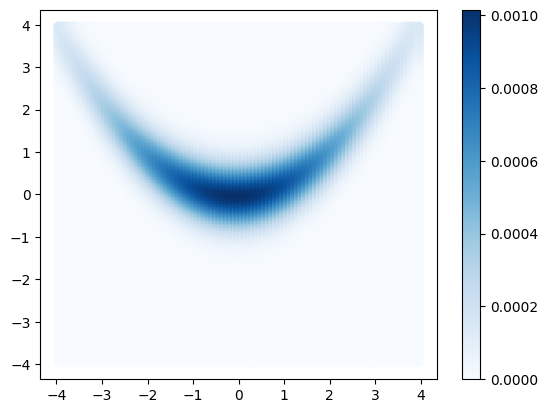

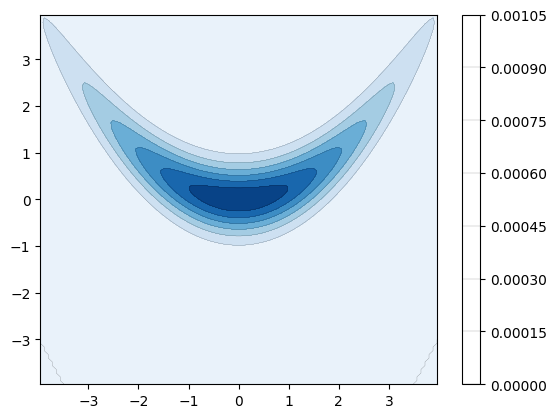

In [29]:
discrete_sampler = discrete_model_sampler(banana_model, loss_fn=neglog_loss(), xs=xs_banana, ys=ys_banana, limits=[[-span, span], [-span, span]], n_mesh=n_mesh, normalize_weights=False, prior_sigma=0.0)
posterior_samples, weights = discrete_sampler.samples_and_weights()
integral, function_values, weights, posterior_samples = integrator(discrete_sampler, functional_evaluation_model, parametersubset, xs_banana)
print(f"When using discrete integration over bnana MODEL we get {integral = }")
plt.scatter(posterior_samples[:,0], posterior_samples[:,1], c=weights, cmap="Blues")
plt.colorbar()
plt.savefig(f"{fig_folder}/banana_distr_discrete.png")
plt.show()

plt.contourf(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy(), cmap="Blues")
plt.contour(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy(), colors="black", linewidths=.1)

plt.colorbar()

plt.savefig(f"{fig_folder}/banana_distr_contour.png")


In [30]:
const_prior = lambda params: torch.tensor(0.0)
loss_fn = neglog_loss()

R_sampler = Riemann_sampler(banana_model, parametersubset, xs=xs_banana, ys=ys_banana, loss_fn=loss_fn, prior_loss=const_prior)
R_sampler.fit(fitting_type="hessian")

R_params=R_sampler.make_posterior_sample(50)


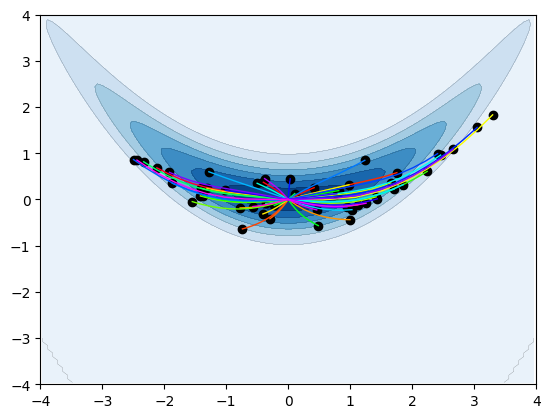

In [31]:
def riemann_plotter(R_sampler, sample_markers=".", plot_traject=True, plot_traj_marker=".", max_samples=None, LA_arrows=[], kde=True, fig=None, ax=None):
    if fig is None:
        fig, ax = plt.subplots()
    cmap = plt.get_cmap("gist_rainbow")
    if plot_traject is True: plot_traject = range(len(R_sampler.trajectories))
    else: plot_traject=[]
    if LA_arrows is True: LA_arrows = range(len(R_sampler.trajectories))
    else: LA_arrows=[]
    if max_samples is None:
        max_samples = len(R_sampler.trajectories)
    if kde:
        df = pd.DataFrame(R_sampler.posterior_samples[:max_samples].numpy(), columns=["x", "y"])
        sns.kdeplot(data=df, x="x", y="y", fill=True, levels=10, color="black", ax=ax)
    if sample_markers is not None:
        ax.scatter(R_sampler.posterior_samples[:max_samples, 0], R_sampler.posterior_samples[:max_samples, 1], c="black")
    for i, sample in enumerate(R_sampler.trajectories[:max_samples]):
        color_no = (i*cmap.N)//len(R_sampler.trajectories[:max_samples])
        if (i in plot_traject) or (plot_traject is True):
            ax.plot(sample[0], sample[1], marker=plot_traj_marker, c=cmap(color_no), linewidth=1)
        if (i in LA_arrows) or (LA_arrows is True):
            dx = R_sampler.posterior_samples_la[i][0] - R_sampler.mean[0]
            dy = R_sampler.posterior_samples_la[i][1] - R_sampler.mean[1]
            ax.arrow(R_sampler.mean[0].detach(), R_sampler.mean[1].detach(), dx.detach(), dy.detach(), head_width=0.1, head_length=0.1, color=cmap(color_no))
    return fig, ax

fig, ax = plt.subplots()
ax.contourf(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy(), cmap="Blues")
plt.contour(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy(), colors="black", linewidths=.1)

fig, ax = riemann_plotter(R_sampler, sample_markers=".", plot_traject=True, plot_traj_marker=None, max_samples=None, LA_arrows=[1], kde=False, fig=fig, ax=ax)
ax.set_xlim(-span, span)
ax.set_ylim(-span, span)
plt.savefig(f"{fig_folder}/banana_distr_contour_riemannshots.png")

plt.show()

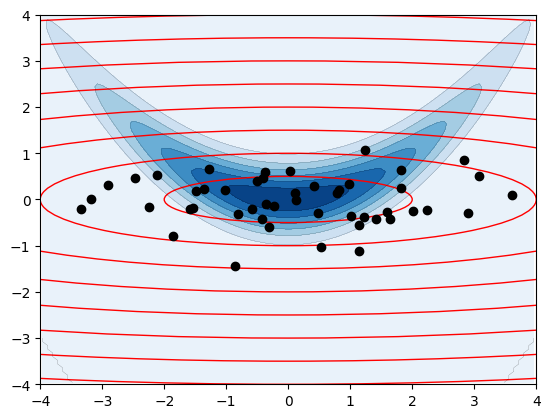

In [32]:
discrete_sampler = discrete_model_sampler(banana_model, loss_fn=neglog_loss(), xs=xs_banana, ys=ys_banana, limits=[[-span, span], [-span, span]], n_mesh=n_mesh, normalize_weights=False, prior_sigma=0.0)
posterior_samples, weights = discrete_sampler.samples_and_weights()
integral, function_values, weights, posterior_samples = integrator(discrete_sampler, functional_evaluation_model, parametersubset, xs_banana)

fig, ax = plt.subplots()
ax.contourf(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy(), cmap="Blues")
ax.contour(posterior_samples[:,0].reshape(n_mesh, n_mesh).detach().numpy(), 
             posterior_samples[:,1].reshape(n_mesh, n_mesh).detach().numpy(), 
             weights.reshape(n_mesh, n_mesh).detach().numpy(), colors="black", linewidths=.1)


eigvals, eigvecs = torch.linalg.eig(R_sampler.covariance)
eigvals = eigvals.real
eigvecs = eigvecs.real
angle = torch.atan(eigvecs[1,0] / eigvecs[0,0])
angle = angle * 180 / 3.14159
for i in range(10):
    ellipse = plt.matplotlib.patches.Ellipse((R_sampler.mean[0].detach(), R_sampler.mean[1].detach()), width=i*eigvals[0].sqrt().detach()*2, height=i*eigvals[1].sqrt().detach()*2, angle=angle, edgecolor="red", facecolor="none")
    ax.add_patch(ellipse)
ax.scatter(R_sampler.posterior_samples_la[:, 0].detach(), R_sampler.posterior_samples_la[:, 1].detach(), c="black")

ax.set_xlim(-span, span)
ax.set_ylim(-span, span)
plt.savefig(f"{fig_folder}/banana_distr_contour_laplace.png")

BQ_1d.steps = 1, observations = 7, integral_mean_BQ = tensor([-0.3239]), integral_variance_BQ = tensor(0.0104)
BQ_1d.steps = 2, observations = 13, integral_mean_BQ = tensor([0.2840]), integral_variance_BQ = tensor(1.6453e-06)


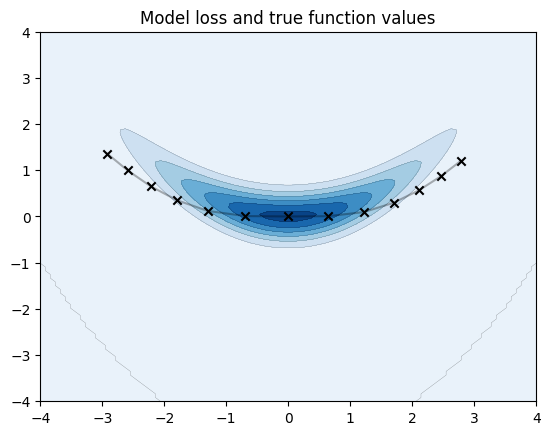

In [34]:

#n_mesh = 200
#curvature = 0.25
#span = 20
#plot_xlim=(-4,4)
#plot_ylim=(-1,4)


banana_function = functional_banana(curvature=curvature, sigma_x=2.0, sigma_y=.5)
xs_banana = torch.tensor([0.0, 0.0]).unsqueeze(0)
ys_banana = banana_function(xs_banana[0]).unsqueeze(0)
class tiny_ridiculess_model_class(torch.nn.Module):
    def __init__(self, n_params):
        super().__init__()
        self.params = torch.nn.Parameter(torch.arange(n_params).float())
    def forward(self, x):
        #return torch.sin(self.params*3.1).sum().repeat(x.shape[0], 1)**2
        #return torch.ones(x.shape[0], 1)
        #return self.params.sum().repeat(x.shape[0], 1)**2
        return self.params.sum().repeat(x.shape[0], 1)

const_prior = lambda x: torch.tensor(0.0)


evaluation_model = tiny_ridiculess_model_class(n_params=2)
functional_evaluation_model = make_functional_fwd_xs(evaluation_model)  # make functional version of model
limits = [[-span, span], [-span, span]]

banana_function_ = lambda x: banana_function(x)
banana_model = Model_from_func(banana_function_, input_shape=[2])
parametersubset = dict(banana_model.named_parameters())
x = torch.tensor([0.0, 0.0])
#print(f"{banana_function(x) = }")
torch.nn.utils.vector_to_parameters(torch.tensor([0.0, 0.0]), banana_model.parameters())
#print(f"{banana_model(x) = }")


####################################
# 6) Bayesian Quadrature - Riemannian laplace integration over model
####################################
R_sampler_2d = Riemann_sampler(banana_model, xs=xs_banana, ys=ys_banana, loss_fn=neglog_loss(), prior_loss=const_prior, subspace_rank=1)
_=R_sampler_2d.fit(fitting_type="hessian")

BQ_1d = BayesianQuadrature_rays(R_sampler_2d, evaluation_model=evaluation_model, measure="gaussian_rescaled", integral_bounds_std=4, 
                             GP_lengthscale=1.0, GP_variance=1.0, num_timesteps=7, use_ray_acqusition=True,  
                             use_rays=True, 
                             theta_space_plot_limits=[[-2,2], [-2,2]], xs = xs_banana[0], parametersubset=None, contour_fill="Blues")
BQ_1d.theta_space_plot_limits=[[-4,4], [-4,4]]

integral_vals_riemann_BQ = []
n_samples_riemann_BQ = []
n_steps= []

for i in range(2):
    integral_mean_BQ, integral_variance_BQ = BQ_1d.step()
    print(f"{BQ_1d.steps = }, observations = {BQ_1d.emukit_method.X.shape[0]}, {integral_mean_BQ = }, {integral_variance_BQ = }")
    integral_vals_riemann_BQ += [integral_mean_BQ]
    n_samples_riemann_BQ += [BQ_1d.emukit_method.X.shape[0]]
    n_steps += [BQ_1d.steps]
ax = plt.subplot()
BQ_1d.plot_model_likelihood_2d(function_vals=False, ax=ax)
plt.savefig(os.path.join(fig_folder, "banana_Riemann_1d_subspace_samples.png"))
plt.show()